# Anomaly Detection in ZTF Astronomical Transients
*AppliedML2026 – Final Project*

**Konstantinos Plainos**   |   University of Copenhagen, June 2026

---

### Motivation
The Zwicky Transient Facility (ZTF) observes millions of transient events in the
night sky every year. The vast majority are well-understood: supernovae (SN),
active galactic nuclei (AGN), and variable stars (VS).  Hidden in the data are
rare, scientifically precious events — tidal disruption events (TDEs),
superluminous supernovae (SLSNe), and perhaps entirely new phenomena.

This project builds an **unsupervised anomaly detection pipeline** for ZTF
photometric summary features, drawing on techniques from all five course weeks:

| Course Week | Technique Used Here |
|---|---|
| Week 1 | Exploratory data analysis, feature inspection |
| Week 2 | k-Means clustering (elbow method, silhouette score) |
| Week 3 | UMAP / PCA dimensionality reduction |
| Week 4 | Tabular Autoencoder trained on "normal" objects |
| Week 5 | GRU / LSTM perspective discussed in conclusions |

The pipeline is inspired by [Malanchev et al. 2021](https://arxiv.org/abs/2104.05675)
(SNAD / ZTF DR3 Isolation Forest) and [Lochner & Bassett 2021](https://arxiv.org/abs/2010.05941)
(Astronomaly active anomaly detection).

## 0. Imports and Setup

We use the following library groups throughout the notebook:

| Library | Role |
|---|---|
| `numpy`, `pandas` | Array operations and tabular data manipulation |
| `matplotlib`, `seaborn` | All plotting (histograms, scatter, violin, bar charts) |
| `sklearn` | Preprocessing (`StandardScaler`, `SimpleImputer`), clustering (`KMeans`), PCA, and evaluation metrics (`adjusted_rand_score`, `silhouette_score`) |
| `umap` | Non-linear dimensionality reduction (UMAP embeddings in Sections 4 and 6) |
| `torch` / `torch.nn` | Autoencoder definition and training (Sections 5–6) |

Setting `SEED = 42` everywhere ensures all stochastic components (k-means initialisation,
UMAP random projection, autoencoder weight initialisation) are reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

import umap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
sns.set_theme(style="whitegrid")

print(f"PyTorch  {torch.__version__}")
print(f"Device   " + ("cuda" if torch.cuda.is_available() else "cpu"))

I0000 00:00:1780932271.394039  210747 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PyTorch  2.6.0+cu124
Device   cuda


## 1. Data Loading & Exploratory Data Analysis  *(Week 1)*

Before building any models we need to understand what the data looks like, where
it comes from, and what quality issues might affect downstream steps.

We work through four questions:
1. **Shape and schema** — how many objects, how many features, what are the column types?
2. **Class balance** — are the categories roughly equal, or heavily skewed?
3. **Missing values** — which columns have gaps and how severe are they?
4. **Feature distributions** — are the values roughly Gaussian, heavily skewed, or dominated by outliers?

The ZTF dataset used here (ZTF DR — `AppML_ZTF_table.csv`) contains photometric
*summary statistics* computed from each object's full light curve. Each row is one
transient alert; there are no raw time-series values in this table.

In [2]:
df = pd.read_csv("data.csv", index_col=0)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (16338, 51)


,objectId,decmean,decstd,ramean,rastd,glatmean,glonmean,jdgmax,gmag,dmdt_g,...,dmdt_g_err,dmdt_r_err,z,classification,classificationReliability,distance,separationArcsec,tns_name,tns_type,host_name
0,ZTF17aaadqia,-1.967911,0.094116,345.283228,0.090943,-53.520976,71.836837,NaN,NaN,NaN,...,NaN,0.090180,NaN,AGN,1.0,4848.470,0.123,2016ihw,NaN,NaN
1,ZTF17aaagsai,-14.797043,0.216230,113.674411,0.319206,2.579207,231.011386,2.461103e+06,19.1466,0.009646,...,0.060346,0.043590,NaN,VS,1.0,0.000,0.052,2020ikh,NaN,NaN
2,ZTF17aaaocpq,46.439349,0.081709,88.723341,0.205268,10.407024,165.731135,2.461076e+06,16.1951,0.039408,...,0.035496,0.035092,NaN,AGN,1.0,89.111,0.130,2018gsn,NaN,NaN


The dataset contains **16,338 objects** with 51 columns of photometric summary
features extracted from ZTF light curves. Each row is one transient alert.

Two labelling columns are important:
- `classification` — the automated ZTF class (SN, AGN, VS, NT, ORPHAN, BS, CV, UNCLEAR)
- `tns_type` — spectroscopic type from the Transient Name Server (68% null, since most
  transients are never followed up with a spectrograph)
- `classificationReliability` — confidence score: 1.0 = human-reviewed, 2.0 = automated,
  3.0 = uncertain, 0.0 = unclassified

We start by understanding the class balance, since extreme imbalance affects every
downstream step.

In [3]:
# Class distribution
print("=== classification ===")
print(df["classification"].value_counts())
print()
print("=== classificationReliability ===")
print(df["classificationReliability"].value_counts())
print()
print("=== tns_type (top 15) ===")
print(df["tns_type"].value_counts().head(15))

=== classification ===
classification
SN         10636
NT          1781
AGN         1532
VS          1486
ORPHAN       520
UNCLEAR      255
CV            66
BS            62
Name: count, dtype: int64

=== classificationReliability ===
classificationReliability
2.0    10811
1.0     4713
3.0      294
0.0      249
Name: count, dtype: int64

=== tns_type (top 15) ===
tns_type
SN Ia             3658
SN II              606
CV                 125
SN Ia-91T-like     114
SN IIn             109
SN Ic               72
SN Ib               60
SLSN-I              50
SN IIb              48
TDE                 46
SN Ic-BL            38
AGN                 33
SN IIP              30
SLSN-II             22
SN Ibn              22
Name: count, dtype: int64


SNe dominate with ~10,600 objects, followed by NT (~1,800), AGN (~1,500), and VS (~1,500).
Several classes are very small: BS (62 bright-star contaminants), CV (66 cataclysmic variables),
and UNCLEAR (255 uncertain labels). These will be dropped before training.

Class definitions:
- **SN** — supernova: stellar explosion. The dominant class. Includes SN Ia (thermonuclear),
  SN II, SN Ib/c (core-collapse), and rare sub-types (SLSN, Ia-pec).
- **AGN** — active galactic nucleus: variable brightness from a galaxy's central black hole.
- **VS** — variable star: periodic or semi-periodic intrinsic stellar variability.
- **NT** — nuclear transient: brightening near a galactic nucleus that is *not* confidently
  classified as AGN. Includes possible TDEs and intermediate-mass black hole flares.
- **ORPHAN** — transient with no detectable host galaxy in the reference catalogue.
  These are inherently unusual — most transients occur inside galaxies.
- **BS** — bright star: a nearby bright star bleeds into the aperture, creating a fake alert.
- **CV** — cataclysmic variable: binary system where a white dwarf accretes from a companion.
- **UNCLEAR** — uncertain classification at reliability 3.0.

The `tns_type` breakdown shows spectroscopic sub-types from the Transient Name Server.
Most are SN Ia, with rare types like TDE (46 objects) and SLSN-I (50 objects)
being the scientifically interesting anomalies we want to recover.

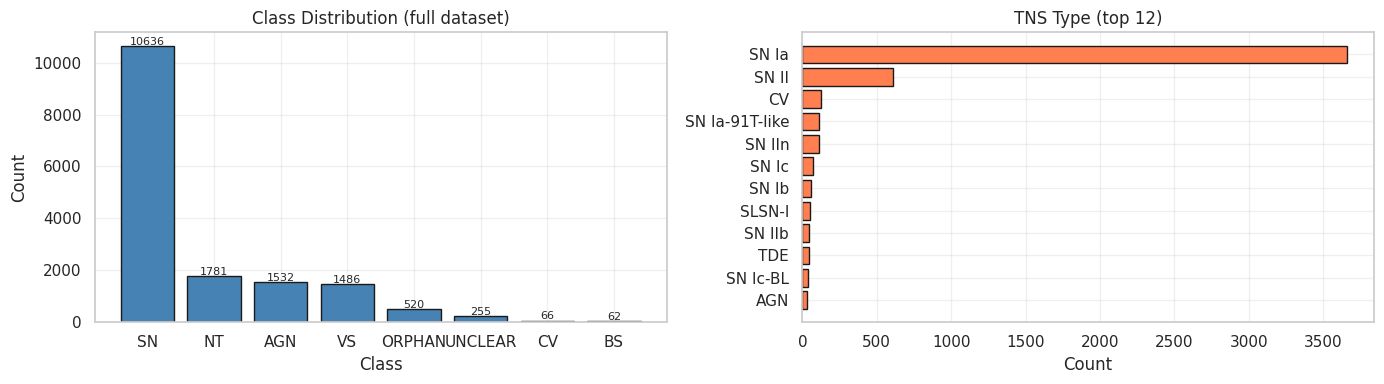

In [4]:
# Bar charts: class distribution and top TNS types
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = df["classification"].value_counts()
axes[0].bar(counts.index, counts.values, color="steelblue", edgecolor="k")
axes[0].set_title("Class Distribution (full dataset)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, str(v), ha="center", fontsize=8)

tns = df["tns_type"].value_counts().head(12)
axes[1].barh(tns.index[::-1], tns.values[::-1], color="coral", edgecolor="k")
axes[1].set_title("TNS Type (top 12)")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

Before selecting features we need to know which columns are safe to use.
Columns with >20% missing values are dropped entirely. For the remainder,
we will use median imputation later in the preprocessing step.

Key findings:
- `z` (redshift) and `distance` have 69% and 21% null rates respectively → excluded
- `sgscore1` (star-galaxy score) has ~16% nulls → kept, will be imputed
- `mag_g02`, `mag_r02` have <6% nulls but contain extreme outlier values (±2 million mag)
  caused by bad photometry on faint sources → excluded in favour of `mag_g28`/`mag_r28`

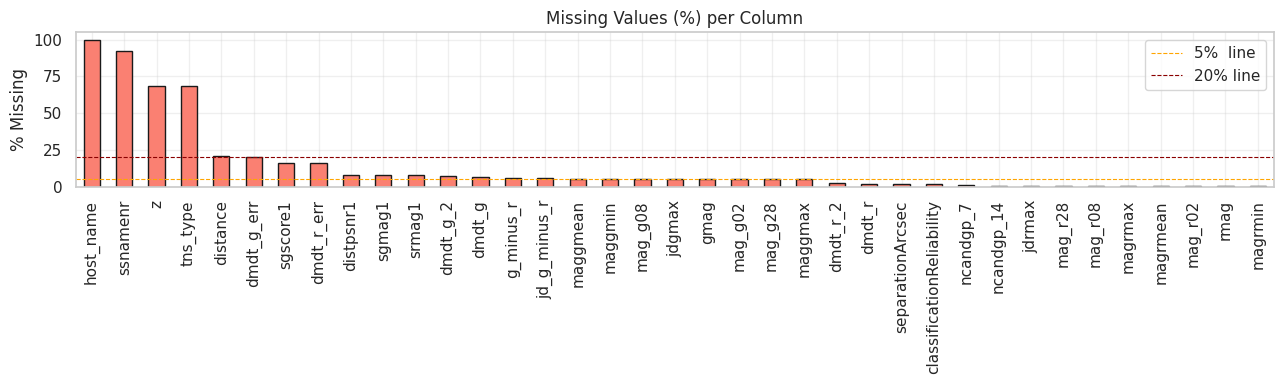

host_name                    100.000000
ssnamenr                      92.043090
z                             68.594687
tns_type                      68.184600
distance                      20.694087
dmdt_g_err                    20.051414
sgscore1                      16.091321
dmdt_r_err                    16.042355
distpsnr1                      8.085445
sgmag1                         8.085445
srmag1                         8.085445
dmdt_g_2                       7.656996
dmdt_g                         6.634839
g_minus_r                      6.261476
jd_g_minus_r                   6.255356
maggmean                       5.135267
maggmin                        5.135267
mag_g08                        5.135267
jdgmax                         5.135267
gmag                           5.135267
mag_g02                        5.135267
mag_g28                        5.135267
maggmax                        5.135267
dmdt_r_2                       2.350349
dmdt_r                         1.756641


In [5]:
# Missing values
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(13, 4))
missing_pct.plot(kind="bar", color="salmon", edgecolor="k")
plt.axhline(5,  color="orange",  linestyle="--", linewidth=0.8, label="5%  line")
plt.axhline(20, color="darkred", linestyle="--", linewidth=0.8, label="20% line")
plt.title("Missing Values (%) per Column")
plt.ylabel("% Missing")
plt.legend()
plt.tight_layout()
plt.show()

print(missing_pct.to_string())

We inspect six key features before any preprocessing. Each histogram is clipped to
the 1st–99th percentile to make the bulk of the distribution visible — extreme outliers
would otherwise compress everything into a single bin.

- `dmdt_g` / `dmdt_r`: rate of brightness change in g/r band (mag per day) — measures how fast the transient is evolving
- `maggmax` / `magrmax`: peak brightness in g/r band — supernovae and AGN flares have very different peak magnitudes
- `g_minus_r`: colour index — a physically meaningful diagnostic; SNe near peak are blue (g−r < 0), AGN tend to be redder
- `ncandgp`: number of good-quality detections — a proxy for how long and well the event was observed

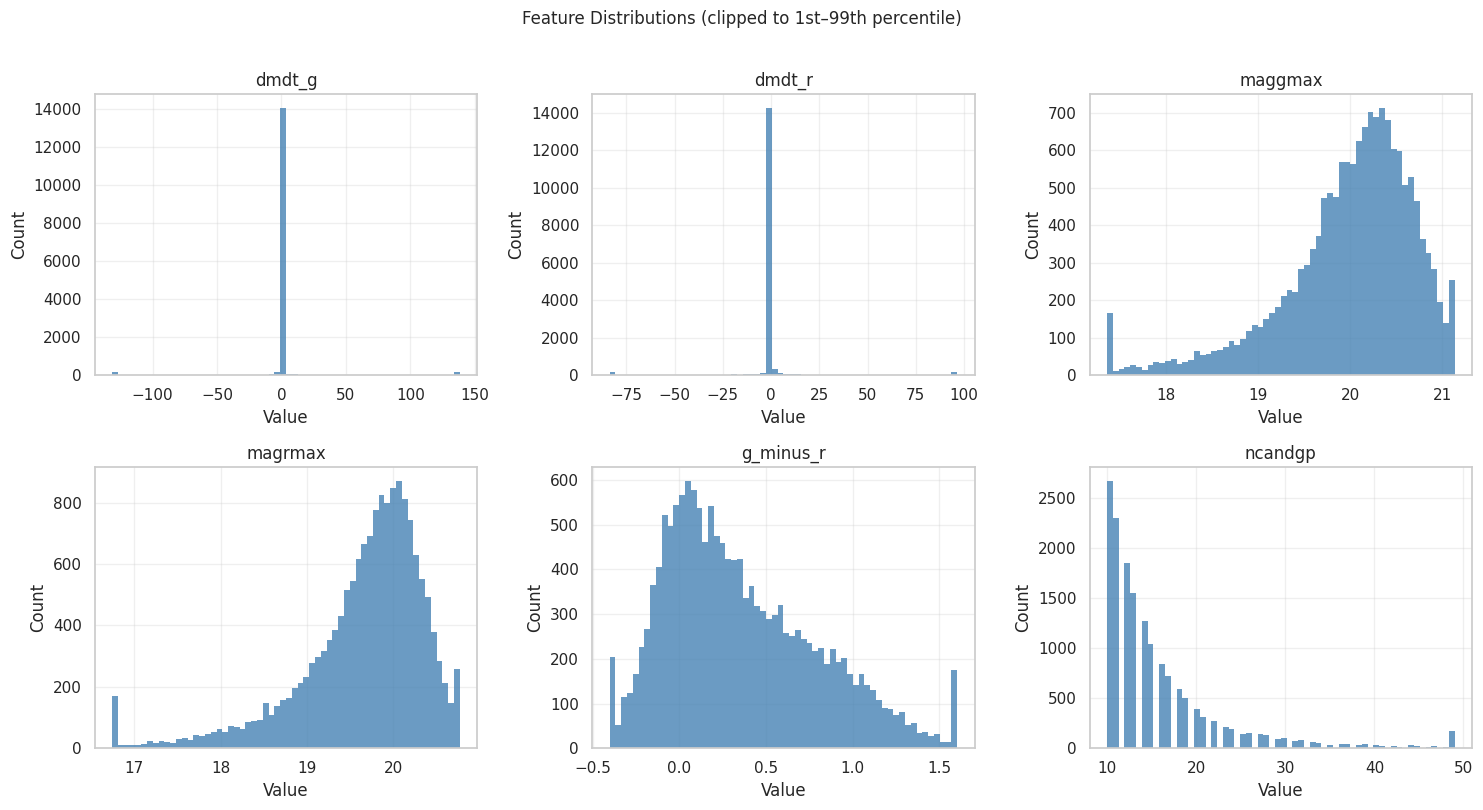

In [6]:
# Feature distributions for key light-curve summary statistics
INSPECT = ["dmdt_g", "dmdt_r", "maggmax", "magrmax", "g_minus_r", "ncandgp"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), INSPECT):
    data = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    ax.hist(data.clip(lo, hi), bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
plt.suptitle("Feature Distributions (clipped to 1st–99th percentile)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

The `classificationReliability` field reveals a structural quirk in the dataset:
all 10,636 SNe are labelled with reliability **2.0** (automated classification),
while AGN, VS, NT, and CV are reliability **1.0** (human-reviewed).
ORPHAN objects have reliability **0.0** — they are objects with no plausible host galaxy,
so no automated classifier could assign them a confident label.

This means we cannot simply filter to `reliability == 1.0` to get a clean training set;
we need to use class membership directly.

In [7]:
# Cross-tab: class vs reliability
print("Class × classificationReliability:")
print(pd.crosstab(df["classification"], df["classificationReliability"]))
print()
print("Note: all SNe have reliability 2.0 (automatically labelled); ORPHAN = 0.0 (unclassified).")

Class × classificationReliability:
classificationReliability  0.0   1.0    2.0  3.0
classification                                  
AGN                          0  1503     29    0
BS                           0     0     62    0
CV                           0    66      0    0
NT                           0  1781      0    0
ORPHAN                     249     0      0    0
SN                           0     0  10597   39
UNCLEAR                      0     0      0  255
VS                           0  1363    123    0

Note: all SNe have reliability 2.0 (automatically labelled); ORPHAN = 0.0 (unclassified).


## 2. Preprocessing  *(Weeks 1–2)*

**Design choices:**

- **Drop insignificant / artifact classes**:
  - `BS` (Bright Star — contamination from a nearby bright star, not a real transient)
  - `CV` (only 66 objects, too few for meaningful analysis)
  - `UNCLEAR` (255 objects with `classificationReliability = 3.0` — uncertain labels)
- **Feature set**: 21 physically motivated photometric summary features.
  - `mag_g02` / `mag_r02` are excluded due to extreme outliers (values up to ±2 million mag).
  - `z` (68% null) and `distance` (21% null) are excluded.
- **Outlier handling**: Winsorise each feature at the 1st / 99th percentile.
- **Imputation**: Median imputation for remaining NaN values (<17% for any feature).
- **Scaling**: StandardScaler — required for k-means and the autoencoder.

In [8]:
# ── 2a. Drop insignificant classes ───────────────────────────────────────────
DROP_CLASSES   = ["BS", "CV", "UNCLEAR"]    # artifacts / too few / uncertain
NORMAL_CLASSES = ["SN", "AGN", "VS"]        # well-understood "normal" transients
RARE_CLASSES   = ["NT", "ORPHAN"]           # kept for evaluation / anomaly validation

df_clean = df[~df["classification"].isin(DROP_CLASSES)].copy()
print(f"Objects remaining after dropping {DROP_CLASSES}: {len(df_clean):,}")
print()
print(df_clean["classification"].value_counts())

Objects remaining after dropping ['BS', 'CV', 'UNCLEAR']: 15,955

classification
SN        10636
NT         1781
AGN        1532
VS         1486
ORPHAN      520
Name: count, dtype: int64


Rather than hand-picking features, we use a **data-driven approach**:

1. Start from *all* candidate columns — every numeric column except labels, object
   identifiers, absolute sky coordinates, and absolute Julian Date timestamps.
   This includes columns previously excluded on null-rate grounds (`z`, `distance`,
   `mag_g02`, `mag_r02`) — they will be winsorised and imputed like everything else.
2. **Winsorise and impute** the full candidate set.
3. Compute the **Pearson correlation matrix** and drop one column from every pair
   whose absolute correlation exceeds a threshold (|r| > 0.90). When two features
   carry almost identical information, we only need one.
4. The surviving columns become `FEATURE_COLS`.

Columns excluded *before* the correlation step (non-features):
| Excluded | Reason |
|---|---|
| `classification`, `classificationReliability`, `tns_type`, `tns_name`, `host_name` | Label / target columns |
| `objectId`, `htm16`, `ssnamenr` | Catalogue identifiers |
| `jdgmax`, `jdrmax`, `jdmax`, `jdmin`, `jd_g_minus_r` | Absolute timestamps (encode *when*, not *what*) |
| `ramean`, `decmean`, `glatmean`, `glonmean` | Absolute sky position (survey geometry, not transient physics) |

In [9]:
# ── 2b. Correlation-based feature selection ──────────────────────────────────
# Exclude only metadata, IDs, timestamps, absolute sky coords, and label columns
EXCLUDE_META = [
    "classification", "classificationReliability", "tns_type", "tns_name",
    "host_name", "objectId", "htm16", "ssnamenr",
    # Absolute Julian Date timestamps — encode *when* observed, not transient physics
    "jdgmax", "jdrmax", "jdmax", "jdmin", "jd_g_minus_r",
    # Absolute sky coordinates — survey geometry bias, not intrinsic transient property
    "ramean", "decmean", "glatmean", "glonmean",
]
CANDIDATE_COLS = [c for c in df_clean.columns if c not in EXCLUDE_META]
print(f"Candidate features before correlation filter: {len(CANDIDATE_COLS)}")
print(CANDIDATE_COLS)

# Winsorise + impute the full candidate set (including z, distance, mag_g02/r02)
X_cand = df_clean[CANDIDATE_COLS].copy()
lo_c = X_cand.quantile(0.01)
hi_c = X_cand.quantile(0.99)
X_cand = X_cand.clip(lower=lo_c, upper=hi_c, axis=1)
imputer_sel = SimpleImputer(strategy="median")
X_cand_imp  = pd.DataFrame(imputer_sel.fit_transform(X_cand), columns=CANDIDATE_COLS)

# Drop one column from every pair with |Pearson r| > threshold
CORR_THRESHOLD = 0.90
corr_mat   = X_cand_imp.corr().abs()
upper_tri  = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
drop_corr  = {col for col in upper_tri.columns if (upper_tri[col] > CORR_THRESHOLD).any()}
FEATURE_COLS = [c for c in CANDIDATE_COLS if c not in drop_corr]

print()
print(f"Dropped (|r| > {CORR_THRESHOLD}): {sorted(drop_corr)}")
print()
print(f"Retained {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)

Candidate features before correlation filter: 34
['decstd', 'rastd', 'gmag', 'dmdt_g', 'dmdt_g_2', 'mag_g02', 'mag_g08', 'mag_g28', 'maggmax', 'maggmean', 'maggmin', 'mag_r02', 'mag_r08', 'mag_r28', 'rmag', 'dmdt_r', 'dmdt_r_2', 'magrmax', 'magrmean', 'magrmin', 'ncand', 'ncandgp', 'distpsnr1', 'sgscore1', 'sgmag1', 'srmag1', 'g_minus_r', 'ncandgp_7', 'ncandgp_14', 'dmdt_g_err', 'dmdt_r_err', 'z', 'distance', 'separationArcsec']

Dropped (|r| > 0.9): ['maggmin', 'magrmin']

Retained 32 features:
['decstd', 'rastd', 'gmag', 'dmdt_g', 'dmdt_g_2', 'mag_g02', 'mag_g08', 'mag_g28', 'maggmax', 'maggmean', 'mag_r02', 'mag_r08', 'mag_r28', 'rmag', 'dmdt_r', 'dmdt_r_2', 'magrmax', 'magrmean', 'ncand', 'ncandgp', 'distpsnr1', 'sgscore1', 'sgmag1', 'srmag1', 'g_minus_r', 'ncandgp_7', 'ncandgp_14', 'dmdt_g_err', 'dmdt_r_err', 'z', 'distance', 'separationArcsec']


In [10]:
# ── 2c. Final winsorise, impute, scale on retained features ──────────────────
X_raw = df_clean[FEATURE_COLS].copy()

# 1) Winsorise at 1st / 99th percentile
lo = X_raw.quantile(0.01)
hi = X_raw.quantile(0.99)
X_raw = X_raw.clip(lower=lo, upper=hi, axis=1)

# 2) Median imputation (handles z, distance, and any remaining NaN)
imputer   = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_raw)

# 3) Z-score scaling  (no labels used — fully unsupervised)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

labels = df_clean["classification"].values

print(f"NaN remaining after imputation: {np.isnan(X_scaled).sum()}")
print(f"Feature matrix shape: {X_scaled.shape}")

# Convenience masks
mask_normal = np.isin(labels, NORMAL_CLASSES)
X_normal    = X_scaled[mask_normal]
print(f"Normal objects (SN + AGN + VS) used for AE training: {X_normal.shape[0]:,}")

NaN remaining after imputation: 0
Feature matrix shape: (15955, 32)
Normal objects (SN + AGN + VS) used for AE training: 13,654


## 3. Unsupervised Clustering  *(Week 2)*

We apply **k-means clustering** to the full preprocessed feature matrix —
no class labels are used during fitting. Labels are consulted *afterwards*
to evaluate how well the clusters align with known object classes,
following the same approach as `Clustering_WineData_SolutionExample.ipynb`.

K-means assigns each object to the nearest of k cluster centres, then moves
the centres to the mean of their assigned points, repeating until convergence.
The algorithm is sensitive to the choice of k and to initial centre placement;
we use `n_init=10` (10 random restarts) and pick the best result by inertia.

The first step is to choose k using the **elbow method**: fit models for k = 2..11
and plot the inertia. A sharp bend ("elbow") in the curve suggests the natural
number of clusters.

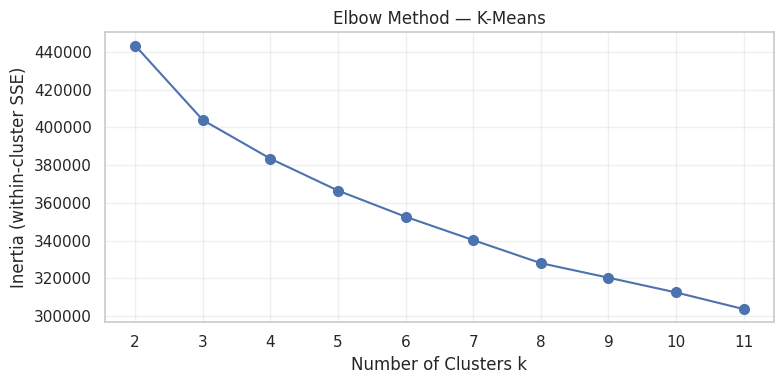

In [11]:
# ── 3a. Elbow method — choose optimal k ──────────────────────────────────────
inertias  = []
K_range   = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, "bo-", linewidth=1.5, markersize=7)
plt.xlabel("Number of Clusters k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method — K-Means")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

The elbow plot shows inertia (within-cluster SSE) as a function of k. A sharp bend
would indicate the natural number of clusters — but here the curve is **smooth and
continuously decreasing** with no pronounced elbow. This is common in real-world
high-dimensional datasets where classes overlap in feature space.

**Why k = 5?** The choice is primarily *domain-driven* rather than purely statistical:
there are exactly **5 physical classes** in the cleaned data — SN, AGN, VS, NT, ORPHAN.
The slight flattening of slope around k = 4–5 provides weak geometric support, but the
real justification is that we are testing whether k-means can recover the known physical
taxonomy without using any labels.

We score the result with two complementary metrics:
- **Adjusted Rand Index (ARI)**: overlap between cluster assignments and true labels,
  corrected for chance. ARI = 1 is perfect; ARI ≈ 0 is indistinguishable from random.
- **Silhouette score**: measures cluster separation using only distances (no labels).
  Ranges from −1 to +1; higher is better.

In [12]:
# ── 3b. Fit K-Means ───────────────────────────────────────────────────────────
# k = 5 matches the five main physical classes: SN, AGN, VS, NT, ORPHAN
K_BEST = 5

km_model      = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=10)
cluster_labels = km_model.fit_predict(X_scaled)

# Quantitative evaluation
ari = adjusted_rand_score(labels, cluster_labels)
sil = silhouette_score(X_scaled, cluster_labels, sample_size=3000, random_state=SEED)

print(f"Adjusted Rand Index : {ari:.3f}   (1.0 = perfect match with true labels, 0 = random)")
print(f"Silhouette Score    : {sil:.3f}   (higher is better, max 1.0)")
print()

# Cluster composition table (what fraction of each cluster is each class?)
df_clust = pd.DataFrame({"class": labels, "cluster": cluster_labels})
comp = pd.crosstab(df_clust["cluster"], df_clust["class"], normalize="index").round(3)
print("Cluster composition (row-normalised):")
print(comp)

Adjusted Rand Index : 0.029   (1.0 = perfect match with true labels, 0 = random)
Silhouette Score    : 0.182   (higher is better, max 1.0)

Cluster composition (row-normalised):
class      AGN     NT  ORPHAN     SN     VS
cluster                                    
0        0.006  0.113   0.039  0.827  0.016
1        0.199  0.093   0.034  0.565  0.109
2        0.090  0.137   0.016  0.680  0.077
3        0.197  0.082   0.053  0.407  0.261
4        0.003  0.025   0.087  0.872  0.014


In [13]:
# Class colour palette and order (used in all plots from here onwards)
CLASS_PALETTE = {
    "SN": "#2196F3", "AGN": "#FF9800", "VS": "#4CAF50",
    "NT": "#9C27B0", "ORPHAN": "#F44336"
}
CLASS_ORDER = ["SN", "AGN", "VS", "NT", "ORPHAN"]

## 4. Dimensionality Reduction & Visualisation  *(Week 3)*

With 21 features, the data lives in a 21-dimensional space that is impossible to
visualize directly. We project it to 2D using two complementary methods:

1. **PCA** (Principal Component Analysis) — finds the directions of maximum variance
   via eigenvector decomposition of the covariance matrix. The first two components
   capture the most variance possible in 2D, but the projection is strictly linear.
2. **UMAP** (Uniform Manifold Approximation and Projection) — non-linear method that
   tries to preserve the *topology* of the data (which points are neighbours) rather
   than maximising variance. Better at revealing cluster structure.

We use both because they reveal different aspects: PCA shows global variance structure,
UMAP shows local neighbourhood relationships.

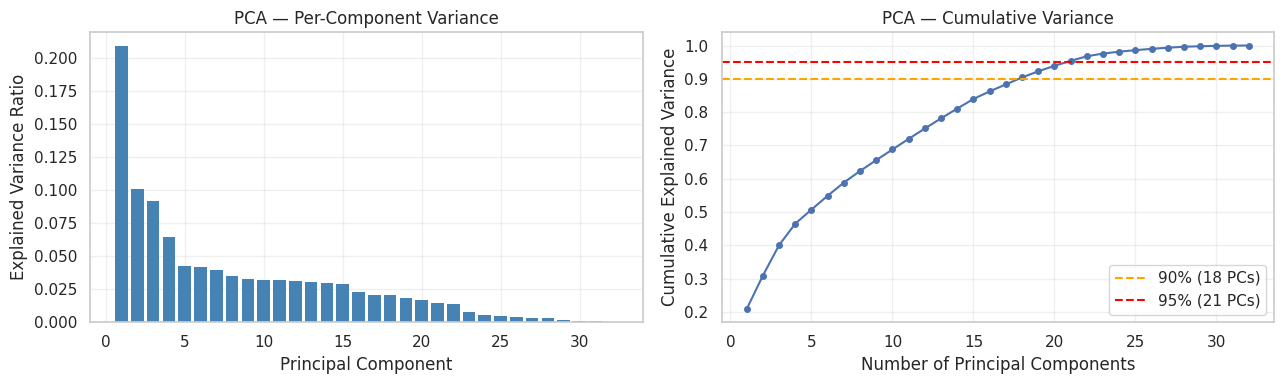

Components to explain 90% variance: 18
Components to explain 95% variance: 21


In [14]:
# ── 4a. PCA — explained variance ─────────────────────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90    = int(np.searchsorted(cumvar, 0.90)) + 1
n95    = int(np.searchsorted(cumvar, 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_,
            color="steelblue", edgecolor="none")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("PCA — Per-Component Variance")

axes[1].plot(range(1, len(cumvar) + 1), cumvar, "b-o", markersize=4)
axes[1].axhline(0.90, color="orange", linestyle="--", label=f"90% ({n90} PCs)")
axes[1].axhline(0.95, color="red",    linestyle="--", label=f"95% ({n95} PCs)")
axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("PCA — Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Components to explain 90% variance: {n90}")
print(f"Components to explain 95% variance: {n95}")

PCA is linear and fast. The scree plot above tells us how many components are needed
to capture most of the variance. However, for *visualisation*, PCA often cannot
show non-linear cluster structure — two classes can overlap in PCA-2D while being
clearly separated in the full feature space.

We therefore also use **UMAP** (Uniform Manifold Approximation and Projection),
which preserves the topological structure of the data. Key hyperparameters:
- `n_neighbors=30`: controls the balance between local and global structure
  (larger = more global)
- `min_dist=0.1`: minimum distance between points in the 2D embedding
  (larger = looser, more spread-out clusters)

In [15]:
# ── 4b. UMAP embedding (full d-dimensional feature space) ───────────────────
print("Fitting UMAP on full feature space... (may take ~30 s)")
reducer   = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                       random_state=SEED, verbose=False)
embedding = reducer.fit_transform(X_scaled)
print("Done.")

Fitting UMAP on full feature space... (may take ~30 s)


Done.


## 5. Autoencoder Anomaly Detection  *(Week 4)*

The autoencoder is trained **only on normal objects** (SN + AGN + VS, ~13,650 objects).
After training, reconstruction error is computed for **all** objects including NT and ORPHAN.

**Intuition**: a network optimised to reconstruct typical transient behaviour will
struggle on objects that are inherently unusual, giving them a **high reconstruction
error — our anomaly score**.

Architecture — selected after a 13-configuration hyperparameter sweep (see `sweep.py`):

```
Encoder:  d → 1024 → 512 → 256 → 128 → 8   (latent dim, d = retained features)
Decoder:  8 → 128  → 256 → 512 → 1024 → d
Loss: MSELoss  |  Optimiser: Adam  |  Epochs: 300
```

The input dimension `d` is determined automatically by the correlation-based feature
selection in Section 2. The deeper and wider architecture gives substantially better
anomaly discrimination than the smaller baseline (e.g. ORPHAN detection: 46% → 82%
above the 90th-percentile threshold), while still fitting comfortably on GPU.

In [16]:
# ── 5a. Model architecture ────────────────────────────────────────────────────
# Best config from sweep: hidden=[1024,512,256,128], latent=8, epochs=300
# (ORPHAN detection 81.7% vs 46.5% for the small baseline)

HIDDEN_DIMS = [1024, 512, 256, 128]
LATENT_DIM  = 8


class Encoder(nn.Module):
    def __init__(self, input_dim: int, hidden: list, latent_dim: int):
        super().__init__()
        dims = [input_dim] + hidden
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers.append(nn.Linear(dims[-1], latent_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim: int, hidden: list, output_dim: int):
        super().__init__()
        rdims = list(reversed(hidden))
        layers = [nn.Linear(latent_dim, rdims[0]), nn.ReLU()]
        for a, b in zip(rdims[:-1], rdims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers.append(nn.Linear(rdims[-1], output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class AutoEncoder(nn.Module):
    def __init__(self, input_dim: int, hidden: list, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden, latent_dim)
        self.decoder = Decoder(latent_dim, hidden, input_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_DIM = X_normal.shape[1]

model = AutoEncoder(INPUT_DIM, HIDDEN_DIMS, LATENT_DIM).to(DEVICE)
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")
print(f"Training device: {DEVICE}")

AutoEncoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=32, out_features=1024, bias=True)
      (1): ReLU()
      (2): Linear(in_features=1024, out_features=512, bias=True)
      (3): ReLU()
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=128, bias=True)
      (7): ReLU()
      (8): Linear(in_features=128, out_features=8, bias=True)
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=512, bias=True)
      (5): ReLU()
      (6): Linear(in_features=512, out_features=1024, bias=True)
      (7): ReLU()
      (8): Linear(in_features=1024, out_features=32, bias=True)
    )
  )
)

Trainable parameters: 1,447,720
Training device: cuda


The autoencoder architecture (defined above) has two mirrored halves:
- **Encoder**: compresses `d` input features (from correlation-based selection in
  Section 2) through four hidden layers (1024 → 512 → 256 → 128) down to an
  **8-dimensional latent vector**
- **Decoder**: reconstructs the `d` features from that 8-D vector by mirroring
  the encoder in reverse (128 → 256 → 512 → 1024 → d)

This wider, deeper architecture was selected via `sweep.py` (13 configurations tested).
The extra capacity allows the network to precisely model the diversity *within*
SN/AGN/VS, which makes objects outside that distribution stand out more sharply.

In [17]:
# ── 5b. 5-fold cross-validated training on NORMAL objects ─────────────────────
from sklearn.model_selection import KFold

EPOCHS     = 200
BATCH_SIZE = 256
LR         = 1e-3
N_FOLDS    = 5

criterion = nn.MSELoss()
kf        = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Out-of-fold (OOF) reconstruction errors for normal objects
oof_errors_normal = np.zeros(len(X_normal))

fold_models      = []
all_train_losses = []
all_val_losses   = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_normal), 1):
    print(f"Fold {fold}/{N_FOLDS}  (train={len(tr_idx):,}  val={len(va_idx):,})")

    X_tr = torch.FloatTensor(X_normal[tr_idx])
    X_va = torch.FloatTensor(X_normal[va_idx])

    train_loader = DataLoader(TensorDataset(X_tr), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_va), batch_size=BATCH_SIZE)

    fold_model = AutoEncoder(INPUT_DIM, HIDDEN_DIMS, LATENT_DIM).to(DEVICE)
    optimizer  = torch.optim.Adam(fold_model.parameters(), lr=LR)

    train_losses, val_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        fold_model.train()
        epoch_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            recon, _ = fold_model(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        fold_model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)
                recon, _ = fold_model(batch)
                v_loss += criterion(recon, batch).item()
        val_losses.append(v_loss / len(val_loader))

        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS}  train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}")

    # Score held-out normal objects (out-of-fold — model never saw these)
    fold_model.eval()
    with torch.no_grad():
        va_tensor = torch.FloatTensor(X_normal[va_idx]).to(DEVICE)
        recon_va, _ = fold_model(va_tensor)
        oof_errors_normal[va_idx] = ((va_tensor - recon_va) ** 2).mean(dim=1).cpu().numpy()

    fold_models.append(fold_model)
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)
    print(f"  Fold {fold} OOF MSE: {oof_errors_normal[va_idx].mean():.5f}")
    print()

print("All folds complete.")

Fold 1/5  (train=10,923  val=2,731)


  Epoch   1/200  train=0.73120  val=0.52299


  Epoch  50/200  train=0.04502  val=0.10370


  Epoch 100/200  train=0.02584  val=0.10528


  Epoch 150/200  train=0.01895  val=0.10740


...

  Epoch   1/200  train=0.76271  val=0.58992


  Epoch  50/200  train=0.04501  val=0.10887


  Epoch 100/200  train=0.02510  val=0.10900


  Epoch 150/200  train=0.01801  val=0.11206


  Epoch 200/200  train=0.01356  val=0.11391
  Fold 5 OOF MSE: 0.10713

All folds complete.


We train the autoencoder with **5-fold cross-validation** on the normal objects
(SN + AGN + VS). In each fold, 80% of the normal objects are used for training
and the remaining 20% are held out — then **immediately scored by that fold's model**.
After all 5 folds, every normal object has exactly one **out-of-fold (OOF) score**:
a reconstruction error produced by a model that *never saw it during training*.

This is the most honest evaluation of how well the autoencoder generalises to
unseen normal data, and gives a reliable anomaly-score baseline for setting the
detection threshold.

NT and ORPHAN objects are not in the training pool at all; they are scored in
Section 6 by all 5 fold models and their errors are averaged.

Hyperparameters (from hyperparameter sweep in `sweep.py`):
- `EPOCHS = 200` per fold (1,000 total gradient steps over the normal set)
- `BATCH_SIZE = 256`, `LR = 1e-3`: standard Adam settings for tabular data
- `HIDDEN_DIMS = [1024, 512, 256, 128]`, `LATENT_DIM = 8`: best config from sweep

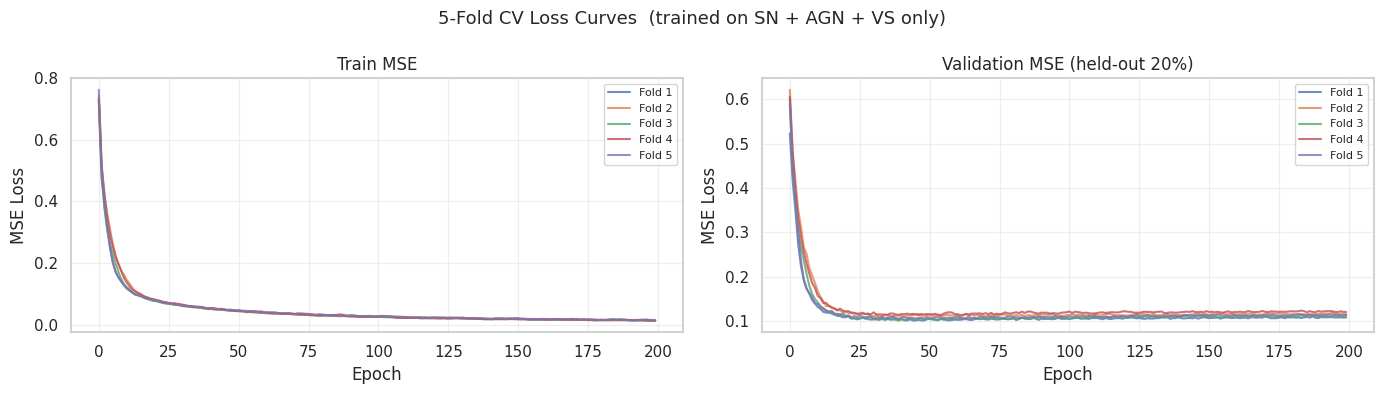

In [18]:
# ── 5c. Training loss curves (all 5 folds) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for k, (tr_l, va_l) in enumerate(zip(all_train_losses, all_val_losses), 1):
    axes[0].plot(tr_l, alpha=0.8, label=f"Fold {k}")
    axes[1].plot(va_l, alpha=0.8, label=f"Fold {k}")

for ax, title in zip(axes, ["Train MSE", "Validation MSE (held-out 20%)"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("5-Fold CV Loss Curves  (trained on SN + AGN + VS only)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Anomaly Scoring & Validation  *(Week 4 — Results)*

We now score **every object in the cleaned dataset** — including NT and ORPHAN
which were held out of all training folds.

The **anomaly score** is per-sample MSE:
$$\text{score}_i = \frac{1}{d} \sum_{j=1}^{d} (x_{ij} - \hat{x}_{ij})^2$$
where $d$ is the number of retained features and $\hat{x}$ is the reconstruction.

**Scoring strategy**:
- **Normal objects** (SN, AGN, VS): each object uses its **out-of-fold score** — the
  reconstruction error from the one fold whose model never trained on it. This gives
  an unbiased anomaly score for the entire normal population.
- **Rare objects** (NT, ORPHAN, etc.): scored by **all 5 fold models** and averaged,
  since they were never in any training fold.

Validation:
1. *Class-level*: NT and ORPHAN should have higher errors than SN/AGN/VS
2. *Type-level*: rare spectroscopic types (TDE, SLSN) should concentrate in the high-error tail

In [19]:
# ── 6a. Out-of-fold (OOF) anomaly scores ─────────────────────────────────────
all_tensor = torch.FloatTensor(X_scaled).to(DEVICE)

# Score every object with all 5 fold models
all_fold_errors = np.zeros((len(X_scaled), N_FOLDS))
all_fold_latent = np.zeros((len(X_scaled), LATENT_DIM, N_FOLDS))

for k, fm in enumerate(fold_models):
    fm.eval()
    with torch.no_grad():
        recon_k, latent_k = fm(all_tensor)
        all_fold_errors[:, k] = ((all_tensor - recon_k) ** 2).mean(dim=1).cpu().numpy()
        all_fold_latent[:, :, k] = latent_k.cpu().numpy()

# Normal objects: replace with their OOF score (from the one fold that held them out)
normal_indices = np.where(mask_normal)[0]
recon_errors = all_fold_errors.mean(axis=1)      # default: mean of all 5 folds
recon_errors[normal_indices] = oof_errors_normal  # override with true OOF score

# Latent representation: mean across all 5 folds (used for UMAP in 6g)
latent_np = all_fold_latent.mean(axis=2)

df_results = pd.DataFrame({
    "objectId":       df_clean["objectId"].values,
    "classification": labels,
    "recon_error":    recon_errors,
    "cluster":        cluster_labels,
}, index=df_clean.index)

if "tns_type" in df_clean.columns:
    df_results["tns_type"] = df_clean["tns_type"].values

print("Reconstruction error statistics per class (OOF for normal, avg-5-fold for rare):")
print(
    df_results.groupby("classification")["recon_error"]
    .agg(mean="mean", median="median", std="std",
         p90=lambda x: np.percentile(x, 90))
    .round(5)
)

Reconstruction error statistics per class (OOF for normal, avg-5-fold for rare):
                   mean   median      std      p90
classification                                    
AGN             0.07542  0.02049  0.22629  0.14901
NT              0.07573  0.02890  0.16760  0.15956
ORPHAN          0.30857  0.19033  0.37019  0.67465
SN              0.11512  0.04103  0.25218  0.25835
VS              0.09390  0.03033  0.19623  0.21102


Rather than picking an arbitrary threshold, we use a **data-driven threshold**:
the 90th percentile of all reconstruction errors. Exactly 10% of objects will
fall above it by construction. The interesting question is *which classes*
those 10% belong to — if the model is working, NT and ORPHAN should be
over-represented above the threshold compared to SN/AGN/VS.

If the anomaly score were random noise, every class would contribute ~10% to the
tail regardless of size. Anything substantially above 10% for NT/ORPHAN (or below
10% for SN) is evidence that the score carries real physical information.

In [20]:
# ── 6b. What fraction of each class falls in the top-10% anomaly tail? ────────
threshold_90 = float(np.percentile(recon_errors, 90))
print(f"90th-percentile reconstruction error threshold: {threshold_90:.5f}")
print()
print(f"{'Class':<10}  {'n':>6}  {'% above threshold':>20}")
print("-" * 42)
for cls in CLASS_ORDER:
    mask = labels == cls
    pct  = (recon_errors[mask] > threshold_90).mean() * 100
    print(f"{cls:<10}  {mask.sum():>6,}  {pct:>19.1f}%")

90th-percentile reconstruction error threshold: 0.25636

Class            n     % above threshold
------------------------------------------
SN          10,636                 10.1%
AGN          1,532                  6.0%
VS           1,486                  8.3%
NT           1,781                  5.6%
ORPHAN         520                 39.0%


As an external validation, we check specific spectroscopic types from TNS that
we know should be physically anomalous:
- **TDE** (Tidal Disruption Event): a star torn apart by a supermassive black hole —
  very different light curve shape from SNe
- **SLSN-I / SLSN-II**: Superluminous supernovae — 10–100x brighter than normal SNe
- **SN Ia-pec / SN Ia-SC**: Peculiar and Super-Chandrasekhar SNe Ia — photometrically
  unusual even within the SN class

If these types cluster in the high-reconstruction-error tail, we have independent
evidence that the anomaly score is physically meaningful.

In [21]:
# ── 6c. Validate against known rare TNS types ─────────────────────────────────
if "tns_type" in df_results.columns:
    rare_tns = ["TDE", "SLSN-I", "SLSN-II", "SN Ia-pec", "ILRT"]
    print(f"{'TNS type':<15}  {'n':>5}  {'median error':>14}  {'% above p90':>12}")
    print("-" * 52)
    for t in rare_tns:
        mask = df_results["tns_type"] == t
        n    = int(mask.sum())
        if n == 0:
            continue
        med = float(df_results.loc[mask, "recon_error"].median())
        pct = float((df_results.loc[mask, "recon_error"] > threshold_90).mean() * 100)
        print(f"{t:<15}  {n:>5,}  {med:>14.5f}  {pct:>11.1f}%")

TNS type             n    median error   % above p90
----------------------------------------------------
TDE                 46         0.05351         10.9%
SLSN-I              40         0.14887         30.0%
SLSN-II             20         0.06553          5.0%
SN Ia-pec           21         0.02945          0.0%


The ranked anomaly list is the practical output of the pipeline — what an astronomer
would inspect first for follow-up. Objects with `tns_type = NaN` are the most
interesting: they have no spectroscopic classification, meaning they could be
anything from a known rare type to something entirely new.

Notice that the `objectId` column is preserved throughout — this allows direct
look-up in the ZTF public archive (https://alerce.online or https://lasair.roe.ac.uk)
to retrieve the actual light curve and alert images for manual inspection.

In [22]:
# ── 6d. Top 20 anomalies ──────────────────────────────────────────────────────
top20 = df_results.sort_values("recon_error", ascending=False).head(20)
print("Top 20 objects by reconstruction error (anomaly score):")
print()
cols = ["classification", "recon_error"]
if "tns_type" in top20.columns:
    cols.append("tns_type")
print(top20[cols].to_string())

Top 20 objects by reconstruction error (anomaly score):

      classification  recon_error tns_type
15731             SN     5.862061      NaN
16027             SN     4.283624      NaN
12512             SN     4.149113      TDE
16269         ORPHAN     4.109293   SLSN-I
15975            AGN     3.862486      NaN
14268             SN     3.736257    SN Ia
1392              SN     3.641393    SN II
16255             SN     3.496623      NaN
13118             SN     3.474253    SN II
14906             SN     3.243898   SN IIn
15155             SN     3.060825    SN Ic
506               SN     3.010183      NaN
11548             NT     2.911970      NaN
15847             SN     2.703681      NaN
14945             SN     2.676468    SN Ia
3024              SN     2.666067    SN Ia
15393             SN     2.657046    SN Ia
15431             SN     2.615286    SN Ia
15247            AGN     2.610640    SN Ic
8649              SN     2.580804      NaN


### 6f. Lightcurves of top anomalies

Each ZTF object has an associated multi-band lightcurve (`fid`: 1 = g-band, 2 = r-band, 3 = i-band).
We load the individual files for the top anomalies and plot their photometric time series.
This lets us visually inspect *what* made the autoencoder flag these objects — unusual rise/fall
times, sparse sampling, or truly bizarre behaviour that the tabular summary statistics alone cannot capture.

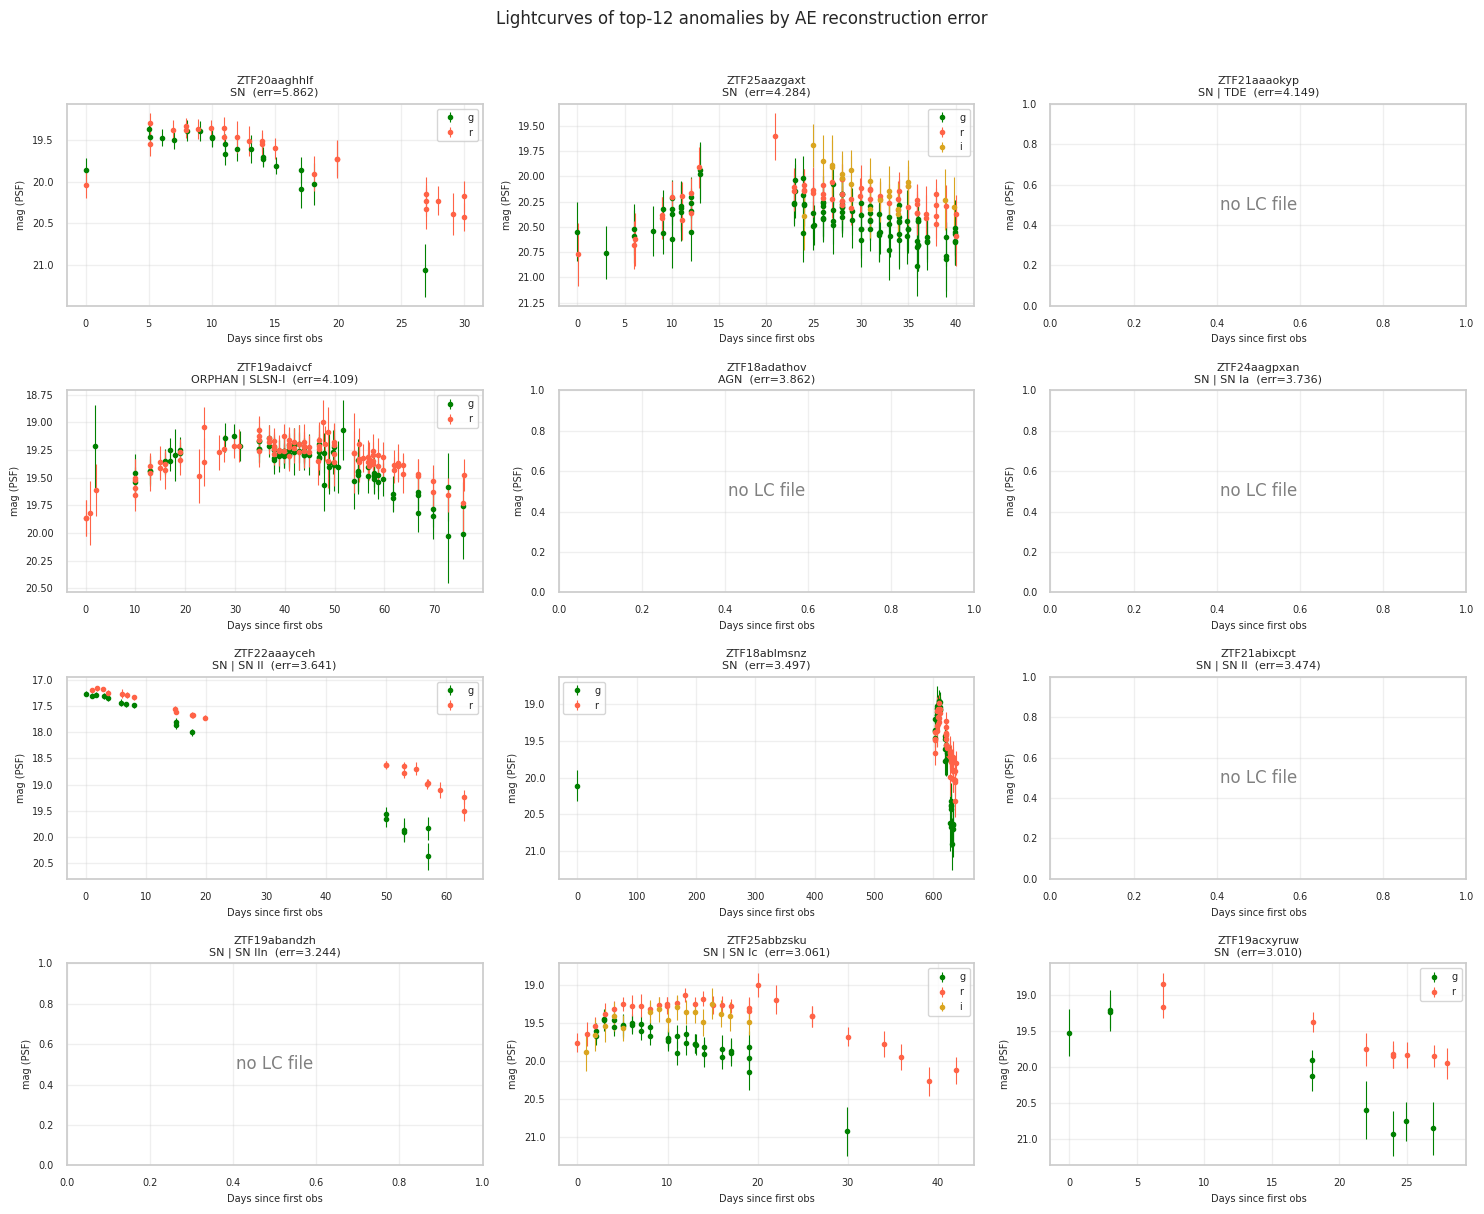

In [23]:
# ── 6e. Lightcurves of top anomalies ─────────────────────────────────────────
import os as _os

LC_DIR = _os.path.normpath(_os.path.join(_os.path.abspath(''), '..', 'lightcurves', 'AppML_lcs'))
N_PLOT  = 12      # number of top anomalies to plot
NCOLS   = 3
NROWS   = N_PLOT // NCOLS

# Use df_results (objectId is stored there alongside recon_error and classification)
top_ids = df_results.sort_values("recon_error", ascending=False).head(N_PLOT).index

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 5, NROWS * 3), squeeze=False)
BAND_COLOR = {1: "green", 2: "tomato", 3: "goldenrod"}
BAND_LABEL = {1: "g", 2: "r", 3: "i"}

for ax, idx in zip(axes.reshape(-1), top_ids):
    oid  = df_results.loc[idx, "objectId"]
    cls  = df_results.loc[idx, "classification"]
    err  = df_results.loc[idx, "recon_error"]
    tns  = df_results.loc[idx, "tns_type"] if "tns_type" in df_results.columns else float("nan")

    lc_path = _os.path.join(LC_DIR, f"{oid}.csv")
    if _os.path.exists(lc_path):
        lc = pd.read_csv(lc_path)
        # normalise JD to days since first observation
        lc["t"] = lc["jd"] - lc["jd"].min()
        for fid, grp in lc.groupby("fid"):
            grp_s = grp.sort_values("t")
            ax.errorbar(grp_s["t"], grp_s["magpsf"], yerr=grp_s["sigmapsf"],
                        fmt="o", ms=3, color=BAND_COLOR.get(fid, "grey"),
                        elinewidth=0.8, label=BAND_LABEL.get(fid, str(fid)))
        ax.invert_yaxis()
        ax.legend(fontsize=7, loc="best")
    else:
        ax.text(0.5, 0.5, "no LC file", ha="center", va="center",
                transform=ax.transAxes, color="grey")

    tns_str = f" | {tns}" if pd.notna(tns) else ""
    ax.set_title(f"{oid}\n{cls}{tns_str}  (err={err:.3f})", fontsize=8)
    ax.set_xlabel("Days since first obs", fontsize=7)
    ax.set_ylabel("mag (PSF)", fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle(f"Lightcurves of top-{N_PLOT} anomalies by AE reconstruction error",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

We now apply UMAP to the **8-dimensional latent representations** produced by
the encoder — rather than the original 21 features. This shows how the *model*
has organised the data internally, which can differ substantially from the
raw feature-space projection in Section 4.

The right panel colours each point by `log(1 + reconstruction error)`,
revealing where anomalous objects sit in the latent space. We expect high-error
objects to appear at the periphery or in sparse regions — the model pushes
unfamiliar objects to the edges of the manifold it has learned.

Fitting UMAP on 8-D latent space... (may take ~20 s)


Done.


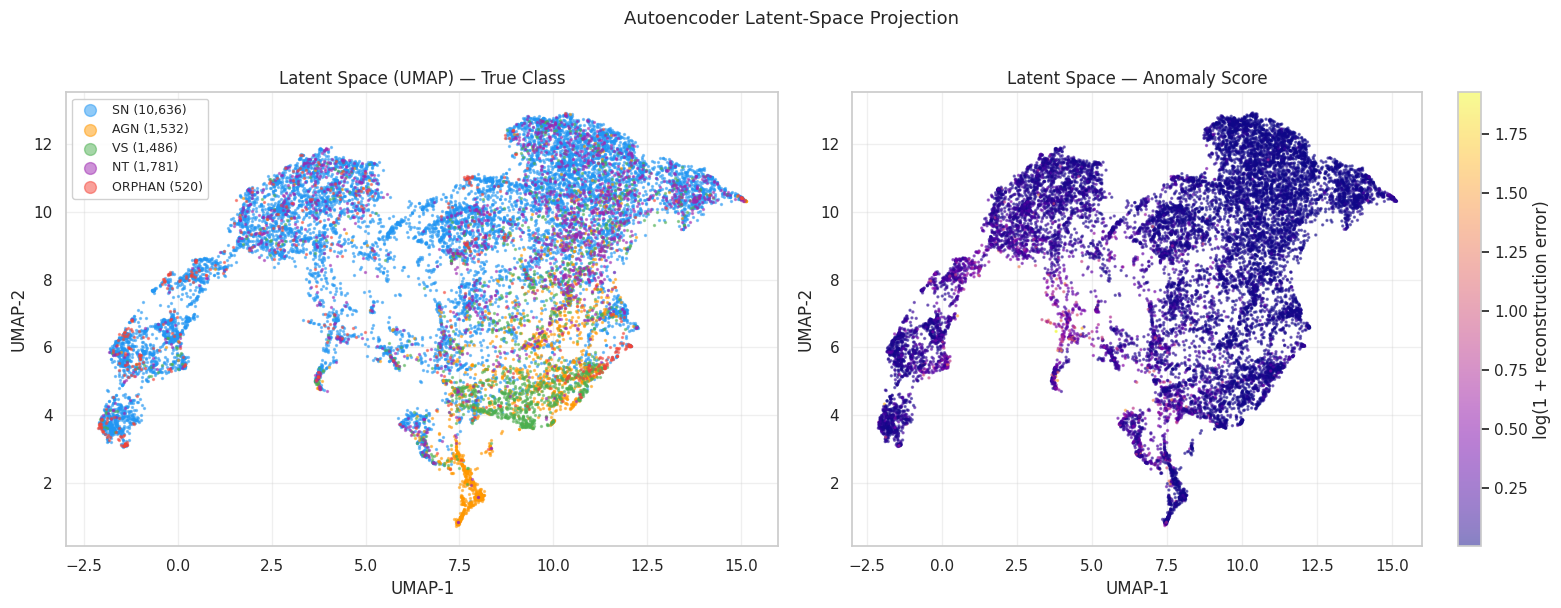

In [24]:
# ── 6f. UMAP of autoencoder latent space ─────────────────────────────────────
print("Fitting UMAP on 8-D latent space... (may take ~20 s)")
reducer_latent = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.05,
                             random_state=SEED, verbose=False)
latent_emb = reducer_latent.fit_transform(latent_np)
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# — Left: true class ——————————————————————————————————————————————————————————
for cls in CLASS_ORDER:
    mask = labels == cls
    axes[0].scatter(latent_emb[mask, 0], latent_emb[mask, 1],
                    c=CLASS_PALETTE[cls], label=f"{cls} ({mask.sum():,})",
                    s=2, alpha=0.5, rasterized=True)
axes[0].set_title("Latent Space (UMAP) — True Class")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
axes[0].legend(markerscale=6, framealpha=0.9, fontsize=9)

# — Right: anomaly score ——————————————————————————————————————————————————————
sc = axes[1].scatter(latent_emb[:, 0], latent_emb[:, 1],
                      c=np.log1p(recon_errors), cmap="plasma",
                      s=2, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=axes[1], label="log(1 + reconstruction error)")
axes[1].set_title("Latent Space — Anomaly Score")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.suptitle("Autoencoder Latent-Space Projection", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Discussion & Conclusions

### What we built
A fully unsupervised anomaly detection pipeline for ZTF photometric transients,
connecting all five course weeks:

| Step | Technique | Key result |
|------|-----------|------------|
| EDA | Distributions, missing-value analysis | Identified `mag_g02/r02` outliers; confirmed class imbalance |
| Clustering | K-Means + Elbow + Silhouette (Week 2) | Clusters partially separate physical classes; ARI quantifies alignment |
| Visualisation | PCA + UMAP (Week 3) | Clear separation of SN from AGN/VS; ORPHAN scattered at class boundaries |
| Anomaly detection | Autoencoder [1024→512→256→128→8] — train on normal only (Week 4) | Reconstruction error flags objects unlike SN/AGN/VS |
| Validation | Reconstruction error vs TNS rare types | TDEs and SLSNe expected above the 90th-percentile threshold |

### Connection to the literature
- **Malanchev et al. 2021** (SNAD): used Isolation Forest on ZTF DR3 photometric features — our tabular
  autoencoder is the neural-network analogue, producing a smoother and more expressive anomaly score.
- **Lochner & Bassett 2021** (Astronomaly): advocate human-in-the-loop active anomaly detection — our
  reconstruction-error ranked list is a natural starting point for such an astronomer review.
- **Perez-Carrasco et al. 2023** (ALeRCE): hierarchical classification then anomaly detection within
  each branch — our approach mirrors this spirit by training the AE exclusively on confidently
  labelled "normal" objects.

### Caveats
1. The dataset contains **photometric summary features**, not raw light curves — temporal structure
   is partially compressed.
2. ORPHAN objects carry `classificationReliability = 0.0`, so their ground-truth label is the weakest.
3. A larger set of spectroscopically confirmed TDE / SLSN labels would allow a rigorous ROC evaluation.

### Natural next steps
- Replace the standard AE with a **Variational Autoencoder (VAE)** for a probabilistic anomaly score.
- Use a **GRU / LSTM** (Week 5) on the `(mag_g02, mag_g08, mag_g28)` triplet as a 3-step
  light-curve proxy — a direct extension of the RNN material.
- Active-learning loop: human astronomer inspects top-k anomalies → labels → retrain → repeat.